# **Interpreting Transformers Models**

In this tutorial we will learn how to interpret BERT using a **medical/clinical QA dataset**. BERT is a transformer-based machine learning technique for natural language processing pre-training developed by Google. This code was originally proposed by [Captum](https://captum.ai/tutorials/Bert_SQUAD_Interpret).

We use a **biomedical question-answering** context inspired by MedQuAD (Medical Question Answer Dataset) to analyze how the model localizes answers in dense, domain-specific text — a critical use case for Explainable AI in healthcare.


In [1]:
# install required python packages
!pip install seaborn
!pip install pandas
!pip install matplotlib
!pip install transformers
!pip install captum



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\skand\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\skand\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\skand\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\skand\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\skand\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
!pip install numpy pandas seaborn matplotlib torch torchvision transformers captum


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\skand\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [1]:
# import required python libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import json

from transformers import BertTokenizer, BertForQuestionAnswering, BertConfig
from captum.attr import visualization as viz
from captum.attr import LayerConductance, LayerIntegratedGradients


c:\Users\skand\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


We use a **bert-base-uncased** model fine-tuned on SQuAD for question answering. This is a standard extractive QA model that predicts start and end positions of an answer span within a given context.

Alternatively, one could use a domain-specific model such as [**dmis-lab/biobert-base-cased-v1.2**](https://huggingface.co/dmis-lab/biobert-base-cased-v1.2), pre-trained on large biomedical corpora (PubMed abstracts, PMC full-text articles) to better capture clinical terminology.


We load a **bert-base-uncased** model pre-trained on the SQuAD dataset for extractive question answering.

After loading, we instantiate both the **BertForQuestionAnswering** model and the **BertTokenizer** using HuggingFace Transformers.


In [3]:
# We use bert-base-uncased fine-tuned on SQuAD for extractive QA
# https://huggingface.co/bert-base-uncased
model_path = "deepset/bert-base-uncased-squad2"

# Alternative: biomedical domain-specific BERT (uncomment to use)
# model_path = "dmis-lab/biobert-base-cased-v1.2"

# load model
model = BertForQuestionAnswering.from_pretrained(model_path)
model.to(device)
model.eval()
model.zero_grad()

# load tokenizer
tokenizer = BertTokenizer.from_pretrained(model_path)


c:\Users\skand\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\skand\.cache\huggingface\hub\models--deepset--bert-base-uncased-squad2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [4]:
def predict(inputs, token_type_ids=None, position_ids=None, attention_mask=None):
    output = model(inputs, token_type_ids=token_type_ids,
                 position_ids=position_ids, attention_mask=attention_mask)
    return output.start_logits, output.end_logits


In [5]:
def squad_pos_forward_func(inputs, token_type_ids=None, position_ids=None, attention_mask=None, position=0):
    pred = predict(inputs,
                   token_type_ids=token_type_ids,
                   position_ids=position_ids,
                   attention_mask=attention_mask)
    pred = pred[position]
    return pred.max(1).values


In [6]:
ref_token_id = tokenizer.pad_token_id  # A token used for generating token reference
sep_token_id = tokenizer.sep_token_id  # A token used as a separator between question and text
cls_token_id = tokenizer.cls_token_id  # A token used for prepending to the concatenated question-text word sequence


In [8]:
def construct_input_ref_pair(question, text, ref_token_id, sep_token_id, cls_token_id):
    question_ids = tokenizer.encode(question, add_special_tokens=False)
    text_ids = tokenizer.encode(text, add_special_tokens=False)

    # construct input token ids
    input_ids = [cls_token_id] + question_ids + [sep_token_id] + text_ids + [sep_token_id]

    # construct reference token ids
    ref_input_ids = [cls_token_id] + [ref_token_id] * len(question_ids) + [sep_token_id] + \
        [ref_token_id] * len(text_ids) + [sep_token_id]

    return torch.tensor([input_ids], device=device), torch.tensor([ref_input_ids], device=device), len(question_ids)

def construct_input_ref_token_type_pair(input_ids, sep_ind=0):
    seq_len = input_ids.size(1)
    token_type_ids = torch.tensor([[0 if i <= sep_ind else 1 for i in range(seq_len)]], device=device)
    ref_token_type_ids = torch.zeros_like(token_type_ids, device=device)
    return token_type_ids, ref_token_type_ids

def construct_input_ref_pos_id_pair(input_ids):
    seq_length = input_ids.size(1)
    position_ids = torch.arange(seq_length, dtype=torch.long, device=device)
    ref_position_ids = torch.zeros(seq_length, dtype=torch.long, device=device)
    position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
    ref_position_ids = ref_position_ids.unsqueeze(0).expand_as(input_ids)
    return position_ids, ref_position_ids

def construct_attention_mask(input_ids):
    return torch.ones_like(input_ids)

def construct_whole_bert_embeddings(input_ids, ref_input_ids, \
                                    token_type_ids=None, ref_token_type_ids=None, \
                                    position_ids=None, ref_position_ids=None):
    input_embeddings = model.bert.embeddings(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
    ref_input_embeddings = model.bert.embeddings(ref_input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
    return input_embeddings, ref_input_embeddings


## New Dataset: Medical Clinical QA

We now define a **biomedical question-context pair** as input for our BERT model. The context is inspired by **MedQuAD** (Medical Question Answer Dataset), a benchmark dataset of question-answer pairs from medical sources such as NIH.

The goal is to observe how the model distributes attention and attribution across dense, domain-specific clinical text — which is fundamentally different from general-domain corpora like Wikipedia (used in SQuAD).

We interpret what the model was focusing on when predicting an answer to the question from the given input context.


In [9]:
# Medical QA pair inspired by MedQuAD (NIH clinical text)
question = "What are the main symptoms of type 2 diabetes?"
text = (
    "Type 2 diabetes is a chronic condition that affects the way the body metabolizes sugar. "
    "The main symptoms include increased thirst, frequent urination, blurred vision, fatigue, and slow-healing sores. "
    "Some people with type 2 diabetes have no symptoms at all. "
    "The condition develops when the body does not produce enough insulin or does not use insulin effectively."
)


We embed the question and the input text, and generate the corresponding baselines/references.

- **construct_whole_bert_embeddings** embeds the word tokens
- **construct_input_ref_pos_id_pair** embeds the positions
- **construct_input_ref_token_type_pair** embeds the token types (segment A = question, segment B = context)

The **reference** (baseline) is a sequence of [PAD] tokens, which serves as the "neutral" input for Integrated Gradients.


In [10]:
input_ids, ref_input_ids, sep_id = construct_input_ref_pair(question, text, ref_token_id, sep_token_id, cls_token_id)
token_type_ids, ref_token_type_ids = construct_input_ref_token_type_pair(input_ids, sep_id)
position_ids, ref_position_ids = construct_input_ref_pos_id_pair(input_ids)
attention_mask = construct_attention_mask(input_ids)

indices = input_ids[0].detach().tolist()
all_tokens = tokenizer.convert_ids_to_tokens(indices)

print("Tokens:", all_tokens)
print("Sequence length:", len(all_tokens))


Tokens: ['[CLS]', 'what', 'are', 'the', 'main', 'symptoms', 'of', 'type', '2', 'diabetes', '?', '[SEP]', 'type', '2', 'diabetes', 'is', 'a', 'chronic', 'condition', 'that', 'affects', 'the', 'way', 'the', 'body', 'meta', '##bol', '##izes', 'sugar', '.', 'the', 'main', 'symptoms', 'include', 'increased', 'thirst', ',', 'frequent', 'ur', '##ination', ',', 'blurred', 'vision', ',', 'fatigue', ',', 'and', 'slow', '-', 'healing', 'sore', '##s', '.', 'some', 'people', 'with', 'type', '2', 'diabetes', 'have', 'no', 'symptoms', 'at', 'all', '.', 'the', 'condition', 'develops', 'when', 'the', 'body', 'does', 'not', 'produce', 'enough', 'insulin', 'or', 'does', 'not', 'use', 'insulin', 'effectively', '.', '[SEP]']
Sequence length: 84


We define the **ground truth answer span** — the exact substring of the context that constitutes the correct answer.

This allows us to compare the model's predicted start/end positions against the expected ones.


In [11]:
# Ground truth answer span
ground_truth = "increased thirst, frequent urination, blurred vision, fatigue, and slow-healing sores"

ground_truth_tokens = tokenizer.encode(ground_truth, add_special_tokens=False)
ground_truth_end_ind = indices.index(ground_truth_tokens[-1])
ground_truth_start_ind = ground_truth_end_ind - len(ground_truth_tokens) + 1

print("Ground truth start index:", ground_truth_start_ind)
print("Ground truth end index:", ground_truth_end_ind)
print("Ground truth tokens:", tokenizer.convert_ids_to_tokens(ground_truth_tokens))


Ground truth start index: 34
Ground truth end index: 51
Ground truth tokens: ['increased', 'thirst', ',', 'frequent', 'ur', '##ination', ',', 'blurred', 'vision', ',', 'fatigue', ',', 'and', 'slow', '-', 'healing', 'sore', '##s']


To obtain our prediction, we use the input, token type, position IDs and default attention mask.

BERT for QA outputs **start logits** and **end logits** for each token position. The predicted answer is the span that maximizes the start and end scores.


In [12]:
start_scores, end_scores = predict(input_ids,
                                   token_type_ids=token_type_ids,
                                   position_ids=position_ids,
                                   attention_mask=attention_mask)

print("Question: ", question)
predicted_answer = " ".join(all_tokens[torch.argmax(start_scores) : torch.argmax(end_scores)+1])
print("Predicted Answer: ", predicted_answer)


Question:  What are the main symptoms of type 2 diabetes?
Predicted Answer:  increased thirst , frequent ur ##ination , blurred vision , fatigue , and slow - healing sore ##s


## Attribution Method 1: LayerIntegratedGradients on BertEmbeddings

There are two different ways of computing attributions for embedding layers:

1. Use **LayerIntegratedGradients** on the full **BertEmbedding** layer (word + position + token type combined).
2. Use **LayerIntegratedGradients** separately on each sub-embedding (**word_embeddings**, **token_type_embeddings**, **position_embeddings**).

We start with option 1: attributing the full embedding block.


In [13]:
lig = LayerIntegratedGradients(squad_pos_forward_func, model.bert.embeddings)

attributions_start, delta_start = lig.attribute(
    inputs=input_ids,
    baselines=ref_input_ids,
    additional_forward_args=(token_type_ids, position_ids, attention_mask, 0),
    return_convergence_delta=True
)
attributions_end, delta_end = lig.attribute(
    inputs=input_ids,
    baselines=ref_input_ids,
    additional_forward_args=(token_type_ids, position_ids, attention_mask, 1),
    return_convergence_delta=True
)


We define a helper function **summarize_attributions** to aggregate attributions across the embedding dimension for each token in the sequence.

Attributions are first summed over the hidden dimension, then **L2-normalized** so values are comparable across tokens.


In [14]:
def summarize_attributions(attributions):
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    return attributions


In [15]:
attributions_start_sum = summarize_attributions(attributions_start)
attributions_end_sum = summarize_attributions(attributions_end)


In [16]:
# Storing visualization records for start and end positions
start_position_vis = viz.VisualizationDataRecord(
                        attributions_start_sum,
                        torch.max(torch.softmax(start_scores[0], dim=0)),
                        torch.argmax(start_scores),
                        torch.argmax(start_scores),
                        str(ground_truth_start_ind),
                        attributions_start_sum.sum(),
                        all_tokens,
                        delta_start)

end_position_vis = viz.VisualizationDataRecord(
                        attributions_end_sum,
                        torch.max(torch.softmax(end_scores[0], dim=0)),
                        torch.argmax(end_scores),
                        torch.argmax(end_scores),
                        str(ground_truth_end_ind),
                        attributions_end_sum.sum(),
                        all_tokens,
                        delta_end)

print("[1m", "Visualizations For Start Position", "[0m")
viz.visualize_text([start_position_vis])

print("[1m", "Visualizations For End Position", "[0m")
viz.visualize_text([end_position_vis])


 Visualizations For Start Position 


 Visualizations For End Position 


In [17]:
## Attribution Method 2: LayerIntegratedGradients on each sub-embedding
# We decompose the attribution into word, token type and position contributions separately
lig2 = LayerIntegratedGradients(squad_pos_forward_func,
                                [model.bert.embeddings.word_embeddings,
                                 model.bert.embeddings.token_type_embeddings,
                                 model.bert.embeddings.position_embeddings])

attributions_start = lig2.attribute(
    inputs=(input_ids, token_type_ids, position_ids),
    baselines=(ref_input_ids, ref_token_type_ids, ref_position_ids),
    additional_forward_args=(attention_mask, 0)
)
attributions_end = lig2.attribute(
    inputs=(input_ids, token_type_ids, position_ids),
    baselines=(ref_input_ids, ref_token_type_ids, ref_position_ids),
    additional_forward_args=(attention_mask, 1)
)

attributions_start_word = summarize_attributions(attributions_start[0])
attributions_end_word = summarize_attributions(attributions_end[0])

attributions_start_token_type = summarize_attributions(attributions_start[1])
attributions_end_token_type = summarize_attributions(attributions_end[1])

attributions_start_position = summarize_attributions(attributions_start[2])
attributions_end_position = summarize_attributions(attributions_end[2])


C:\Users\skand\AppData\Local\Temp\ipykernel_3792\3823220425.py:3: UserWarning: Multiple layers provided. Please ensure that each layer is**not** solely dependent on the outputs ofanother layer. Please refer to the documentation for moredetail.
  lig2 = LayerIntegratedGradients(squad_pos_forward_func,


In [18]:
def get_topk_attributed_tokens(attrs, k=5):
    values, indices = torch.topk(attrs, k)
    top_tokens = [all_tokens[idx] for idx in indices]
    return top_tokens, values, indices


In [19]:
top_words_start, top_words_val_start, top_word_ind_start = get_topk_attributed_tokens(attributions_start_word)
top_words_end, top_words_val_end, top_words_ind_end = get_topk_attributed_tokens(attributions_end_word)

top_token_type_start, top_token_type_val_start, top_token_type_ind_start = get_topk_attributed_tokens(attributions_start_token_type)
top_token_type_end, top_token_type_val_end, top_token_type_ind_end = get_topk_attributed_tokens(attributions_end_token_type)

top_pos_start, top_pos_val_start, pos_ind_start = get_topk_attributed_tokens(attributions_start_position)
top_pos_end, top_pos_val_end, pos_ind_end = get_topk_attributed_tokens(attributions_end_position)

df_start = pd.DataFrame({
    "Word(Index), Attribution": ["{} ({}), {}".format(word, pos, round(val.item(),2))
                                 for word, pos, val in zip(top_words_start, top_word_ind_start, top_words_val_start)],
    "Token Type(Index), Attribution": ["{} ({}), {}".format(ttype, pos, round(val.item(),2))
                                        for ttype, pos, val in zip(top_token_type_start, top_token_type_ind_start, top_words_val_start)],
    "Position(Index), Attribution": ["{} ({}), {}".format(position, pos, round(val.item(),2))
                                      for position, pos, val in zip(top_pos_start, pos_ind_start, top_pos_val_start)]
})

df_end = pd.DataFrame({
    "Word(Index), Attribution": ["{} ({}), {}".format(word, pos, round(val.item(),2))
                                 for word, pos, val in zip(top_words_end, top_words_ind_end, top_words_val_end)],
    "Token Type(Index), Attribution": ["{} ({}), {}".format(ttype, pos, round(val.item(),2))
                                        for ttype, pos, val in zip(top_token_type_end, top_token_type_ind_end, top_words_val_end)],
    "Position(Index), Attribution": ["{} ({}), {}".format(position, pos, round(val.item(),2))
                                      for position, pos, val in zip(top_pos_end, pos_ind_end, top_pos_val_end)]
})

["{}({})".format(token, str(i)) for i, token in enumerate(all_tokens)]


['[CLS](0)',
 'what(1)',
 'are(2)',
 'the(3)',
 'main(4)',
 'symptoms(5)',
 'of(6)',
 'type(7)',
 '2(8)',
 'diabetes(9)',
 '?(10)',
 '[SEP](11)',
 'type(12)',
 '2(13)',
 'diabetes(14)',
 'is(15)',
 'a(16)',
 'chronic(17)',
 'condition(18)',
 'that(19)',
 'affects(20)',
 'the(21)',
 'way(22)',
 'the(23)',
 'body(24)',
 'meta(25)',
 '##bol(26)',
 '##izes(27)',
 'sugar(28)',
 '.(29)',
 'the(30)',
 'main(31)',
 'symptoms(32)',
 'include(33)',
 'increased(34)',
 'thirst(35)',
 ',(36)',
 'frequent(37)',
 'ur(38)',
 '##ination(39)',
 ',(40)',
 'blurred(41)',
 'vision(42)',
 ',(43)',
 'fatigue(44)',
 ',(45)',
 'and(46)',
 'slow(47)',
 '-(48)',
 'healing(49)',
 'sore(50)',
 '##s(51)',
 '.(52)',
 'some(53)',
 'people(54)',
 'with(55)',
 'type(56)',
 '2(57)',
 'diabetes(58)',
 'have(59)',
 'no(60)',
 'symptoms(61)',
 'at(62)',
 'all(63)',
 '.(64)',
 'the(65)',
 'condition(66)',
 'develops(67)',
 'when(68)',
 'the(69)',
 'body(70)',
 'does(71)',
 'not(72)',
 'produce(73)',
 'enough(74)',
 'insulin

In [20]:
df_start


,"Word(Index), Attribution","Token Type(Index), Attribution","Position(Index), Attribution"
0,"people (54), 0.43","thirst (35), 0.43","symptoms (5), 0.46"
1,"some (53), 0.41","diabetes (14), 0.41","way (22), 0.36"
2,"way (22), 0.41","increased (34), 0.41","2 (8), 0.28"
3,"body (70), 0.28","meta (25), 0.28","effectively (81), 0.28"
4,"all (63), 0.24",", (36), 0.24","2 (13), 0.27"


In [21]:
df_end


,"Word(Index), Attribution","Token Type(Index), Attribution","Position(Index), Attribution"
0,"people (54), 0.43","thirst (35), 0.43","symptoms (5), 0.42"
1,"some (53), 0.42","diabetes (14), 0.42","way (22), 0.39"
2,"way (22), 0.4","meta (25), 0.4","effectively (81), 0.31"
3,"body (70), 0.3","the (23), 0.3","2 (13), 0.25"
4,"all (63), 0.25","body (24), 0.25","2 (8), 0.21"


In [22]:
def squad_pos_forward_func2(input_emb, attention_mask=None, position=0):
    pred = model(inputs_embeds=input_emb, attention_mask=attention_mask)
    pred = pred[position]
    return pred.max(1).values


## LayerConductance: Attribution per Transformer Layer

We now use **LayerConductance** to analyze how attributions are distributed across all 12 BERT encoder layers.

This allows us to understand **which layers** are the most responsible for locating the answer span in the medical context — particularly relevant in clinical text where terminology is dense and polysemic.

We also inspect the attribution distribution for a **specific token of interest** (e.g., a key symptom word) across all layers.


In [27]:
layer_attrs_start = []
layer_attrs_end = []

# We examine the attribution of a specific token across layers
# Choose the index of a clinically relevant token (e.g. "thirst", "fatigue")
# Inspect all_tokens to find the index of your token of interest
print("Tokens with indices:")
for i, tok in enumerate(all_tokens):
    print(f"  [{i}] {tok}")

# Update this index to match the token you want to track
token_to_explain = all_tokens.index("thirst") if "thirst" in all_tokens else 14
print(f"Tracking token [{token_to_explain}]: {all_tokens[token_to_explain]}")

layer_attrs_start_dist = []
layer_attrs_end_dist = []

input_embeddings, ref_input_embeddings = construct_whole_bert_embeddings(
    input_ids, ref_input_ids,
    token_type_ids=token_type_ids, ref_token_type_ids=ref_token_type_ids,
    position_ids=position_ids, ref_position_ids=ref_position_ids
)

for i in range(model.config.num_hidden_layers):
    lc = LayerConductance(
    squad_pos_forward_func2,
    model.bert.encoder.layer[i].output
    )    
    layer_attributions_start = lc.attribute(
        inputs=input_embeddings, baselines=ref_input_embeddings,
        additional_forward_args=(attention_mask, 0)
    )
    layer_attributions_end = lc.attribute(
        inputs=input_embeddings, baselines=ref_input_embeddings,
        additional_forward_args=(attention_mask, 1)
    )
    layer_attrs_start.append(summarize_attributions(layer_attributions_start).cpu().detach().tolist())
    layer_attrs_end.append(summarize_attributions(layer_attributions_end).cpu().detach().tolist())

    layer_attrs_start_dist.append(layer_attributions_start[0, token_to_explain, :].cpu().detach().tolist())
    layer_attrs_end_dist.append(layer_attributions_end[0, token_to_explain, :].cpu().detach().tolist())


Tokens with indices:
  [0] [CLS]
  [1] what
  [2] are
  [3] the
  [4] main
  [5] symptoms
  [6] of
  [7] type
  [8] 2
  [9] diabetes
  [10] ?
  [11] [SEP]
  [12] type
  [13] 2
  [14] diabetes
  [15] is
  [16] a
  [17] chronic
  [18] condition
  [19] that
  [20] affects
  [21] the
  [22] way
  [23] the
  [24] body
  [25] meta
  [26] ##bol
  [27] ##izes
  [28] sugar
  [29] .
  [30] the
  [31] main
  [32] symptoms
  [33] include
  [34] increased
  [35] thirst
  [36] ,
  [37] frequent
  [38] ur
  [39] ##ination
  [40] ,
  [41] blurred
  [42] vision
  [43] ,
  [44] fatigue
  [45] ,
  [46] and
  [47] slow
  [48] -
  [49] healing
  [50] sore
  [51] ##s
  [52] .
  [53] some
  [54] people
  [55] with
  [56] type
  [57] 2
  [58] diabetes
  [59] have
  [60] no
  [61] symptoms
  [62] at
  [63] all
  [64] .
  [65] the
  [66] condition
  [67] develops
  [68] when
  [69] the
  [70] body
  [71] does
  [72] not
  [73] produce
  [74] enough
  [75] insulin
  [76] or
  [77] does
  [78] not
  [79] use
  [8

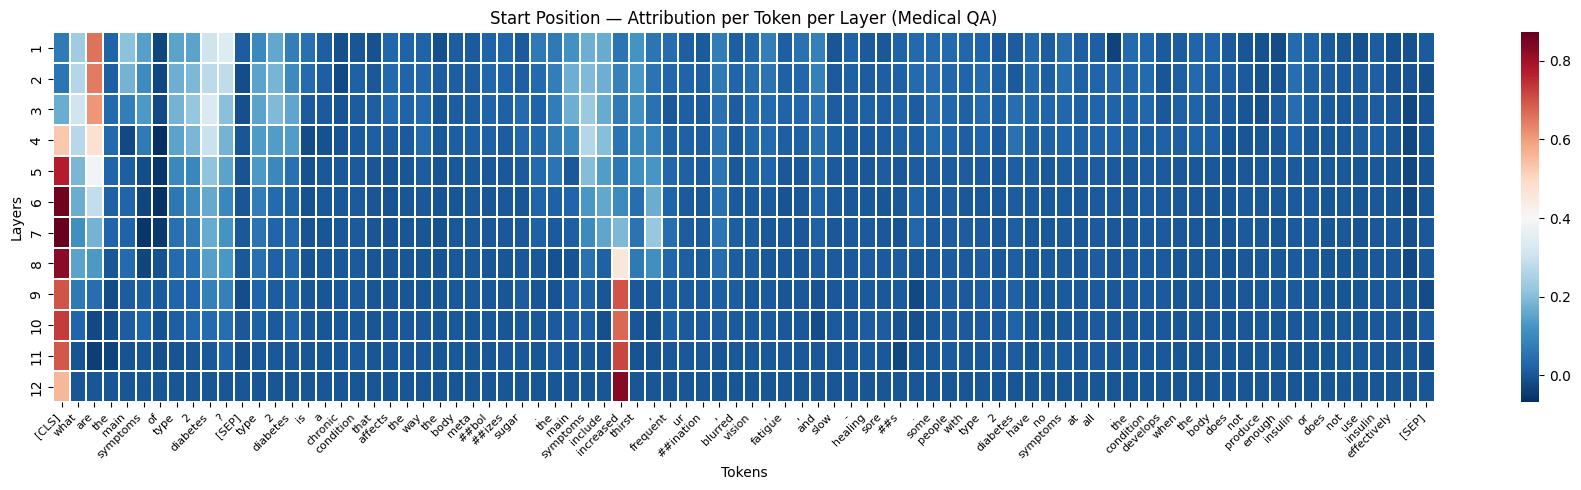

In [28]:
# Heatmap of token attributions per layer — START position
fig, ax = plt.subplots(figsize=(18, 5))
xticklabels = all_tokens
yticklabels = list(range(1, 13))
ax = sns.heatmap(np.array(layer_attrs_start), xticklabels=xticklabels, yticklabels=yticklabels, linewidth=0.2, cmap="RdBu_r")
plt.xlabel("Tokens")
plt.ylabel("Layers")
plt.title("Start Position — Attribution per Token per Layer (Medical QA)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()


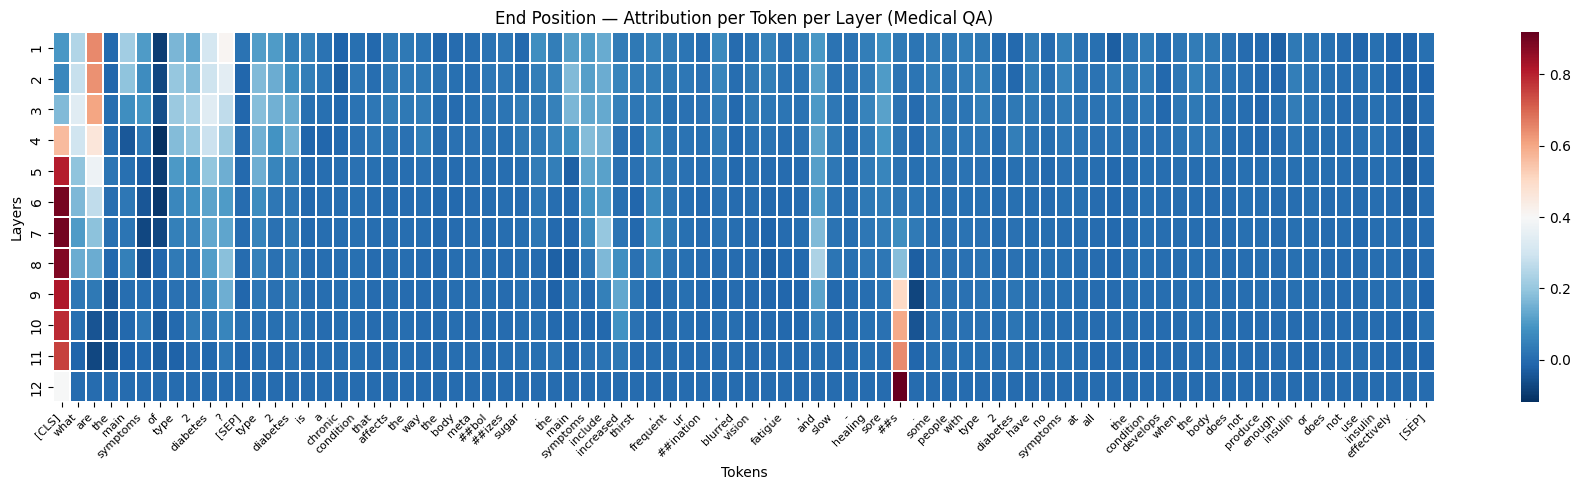

In [29]:
# Heatmap of token attributions per layer — END position
fig, ax = plt.subplots(figsize=(18, 5))
xticklabels = all_tokens
yticklabels = list(range(1, 13))
ax = sns.heatmap(np.array(layer_attrs_end), xticklabels=xticklabels, yticklabels=yticklabels, linewidth=0.2, cmap="RdBu_r")
plt.xlabel("Tokens")
plt.ylabel("Layers")
plt.title("End Position — Attribution per Token per Layer (Medical QA)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()


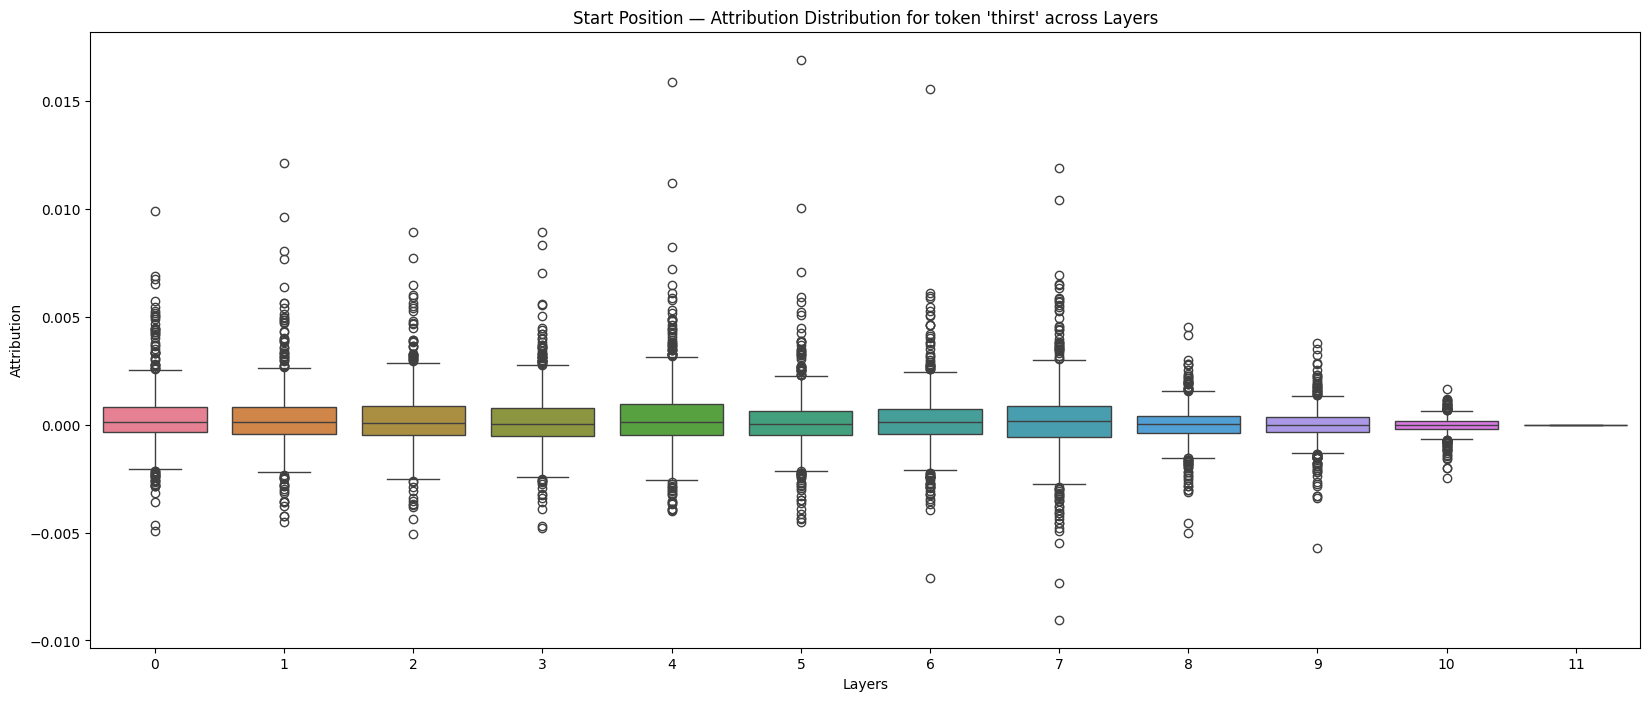

In [31]:
# Distribution of attributions for the tracked token across layers — START
fig, ax = plt.subplots(figsize=(20, 8))
ax = sns.boxplot(data=layer_attrs_start_dist)
plt.xlabel("Layers")
plt.ylabel("Attribution")
plt.title(f"Start Position — Attribution Distribution for token '{all_tokens[token_to_explain]}' across Layers")
plt.show()


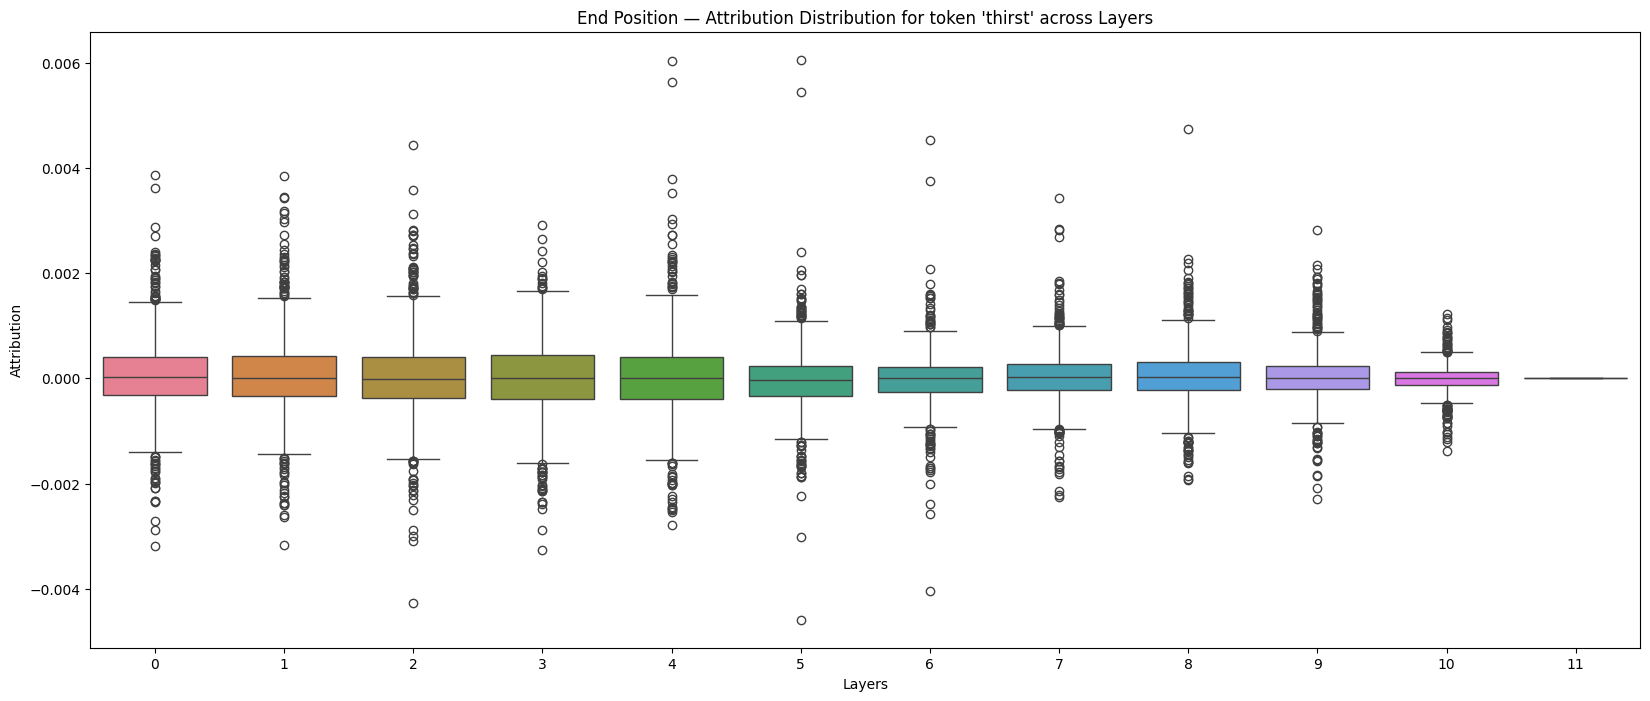

In [33]:
# Distribution of attributions for the tracked token across layers — END
fig, ax = plt.subplots(figsize=(20, 8))
ax = sns.boxplot(data=layer_attrs_end_dist)
plt.xlabel("Layers")
plt.ylabel("Attribution")
plt.title(f"End Position — Attribution Distribution for token '{all_tokens[token_to_explain]}' across Layers")
plt.show()


In [34]:
def pdf_attr(attrs, bins=100):
    return np.histogram(attrs, bins=bins, density=True)[0]


In [35]:
layer_attrs_end_pdf = map(lambda x: pdf_attr(x), layer_attrs_end_dist)
layer_attrs_end_pdf = np.array(list(layer_attrs_end_pdf))

# Summing attribution along embedding dimension for each layer
attr_sum = np.array(layer_attrs_end_dist).sum(-1)

# L1 normalization per layer
layer_attrs_end_pdf_norm = np.linalg.norm(layer_attrs_end_pdf, axis=-1, ord=1)

# Transpose: bins x layers
layer_attrs_end_pdf = np.transpose(layer_attrs_end_pdf)

# Normalize
layer_attrs_end_pdf = np.divide(layer_attrs_end_pdf, layer_attrs_end_pdf_norm,
                                where=layer_attrs_end_pdf_norm != 0)


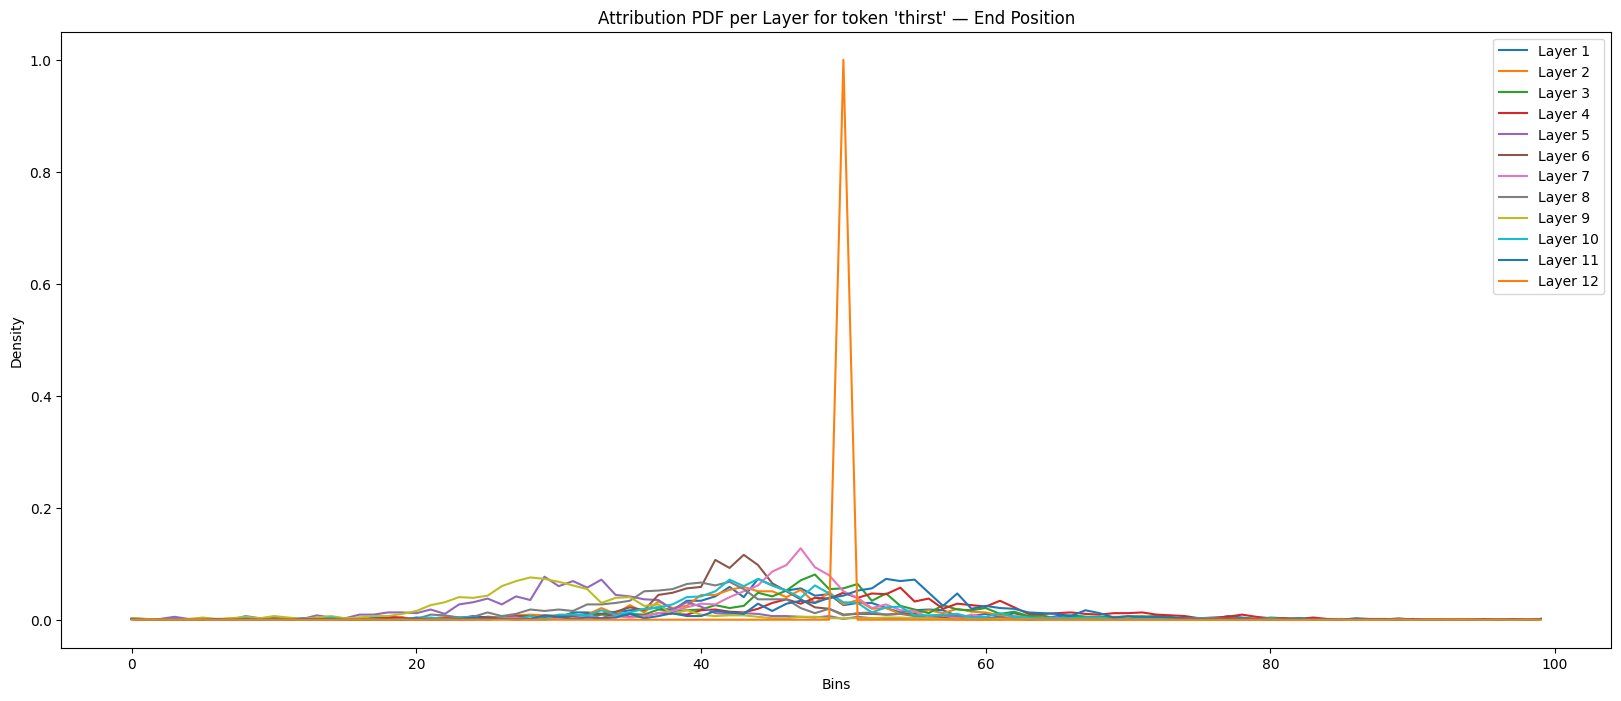

In [37]:
# Density plot of attribution distributions across layers
fig, ax = plt.subplots(figsize=(20, 8))
plt.plot(layer_attrs_end_pdf)
plt.xlabel("Bins")
plt.ylabel("Density")
plt.title(f"Attribution PDF per Layer for token '{all_tokens[token_to_explain]}' — End Position")
plt.legend(["Layer " + str(i) for i in range(1, 13)])
plt.show()


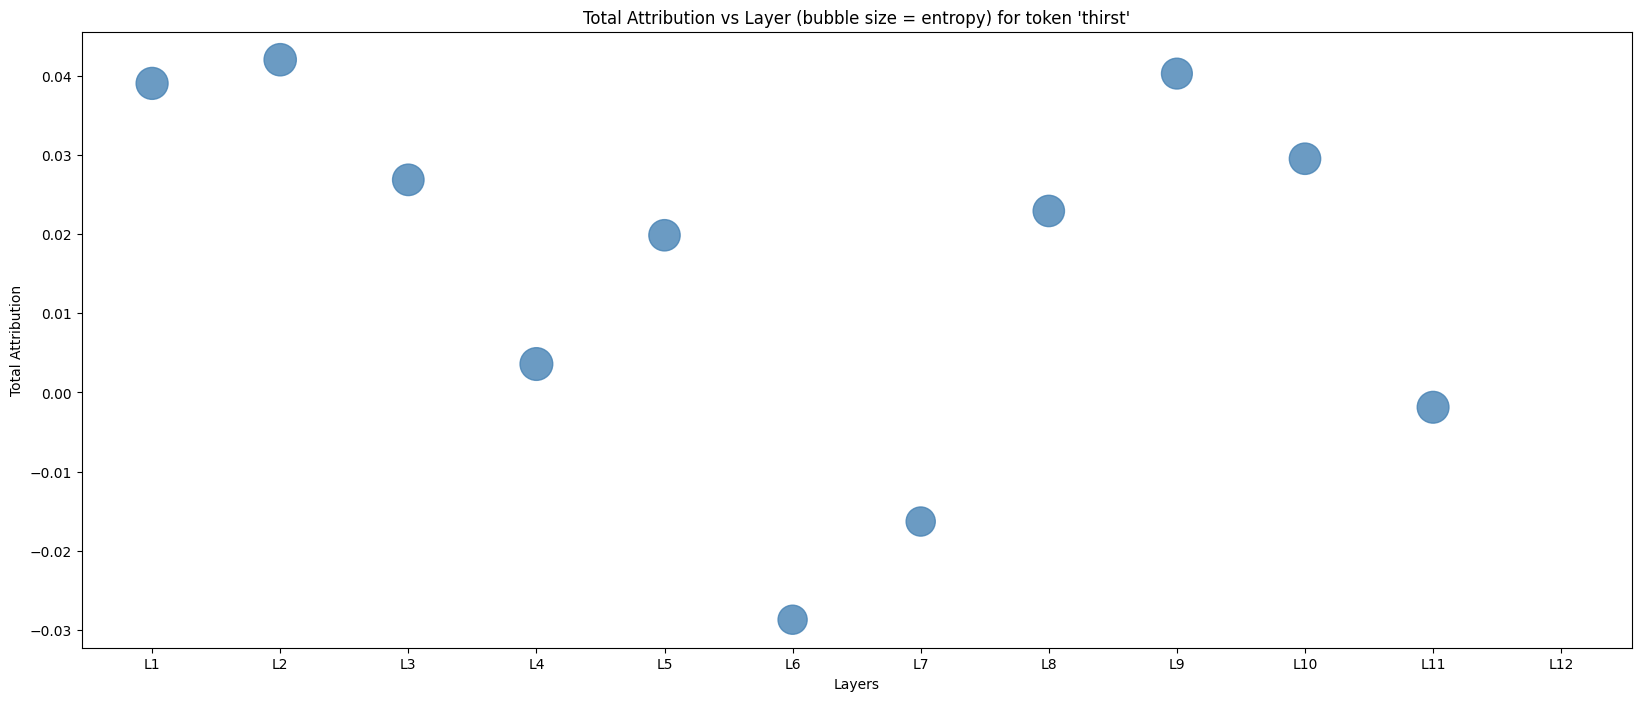

In [39]:
# Entropy-weighted scatter: Total Attribution vs Layer, point size = entropy
fig, ax = plt.subplots(figsize=(20, 8))

# Replace 0s before log (log(1)=0, log(0)=-inf)
layer_attrs_end_pdf[layer_attrs_end_pdf == 0] = 1
layer_attrs_end_pdf_log = np.log2(layer_attrs_end_pdf)

# Shannon entropy per layer
entropies = -(layer_attrs_end_pdf * layer_attrs_end_pdf_log).sum(0)

plt.scatter(np.arange(12), attr_sum, s=entropies * 100, color="steelblue", alpha=0.8)
plt.xlabel("Layers")
plt.ylabel("Total Attribution")
plt.title(f"Total Attribution vs Layer (bubble size = entropy) for token '{all_tokens[token_to_explain]}'")
plt.xticks(np.arange(12), [f"L{i+1}" for i in range(12)])
plt.show()
